# Red Neuronal (100 puntos de envolvente) para el cálculo del espectro de helicenos
Predicción de 100 puntos del espectro completo de las moléculas de heliceno.

## 1. Imports y Configuración y Normalización de los datos.

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow Version:", tf.__version__)

# ====================================================================
# 1. CARGA DE DATOS (13.000 MOLÉCULAS)
# ====================================================================
csv_file = '../Bases de datos/Dataset_envolventes.csv'
df = pd.read_csv(csv_file)

# Separar X (Entradas) e Y (Salidas)
# X: Columnas de la 1 a la 16 (Hammett)
# Y: Columnas de la 17 en adelante (Espectro de 100 puntos)
X_data = df.iloc[:, 1:17].values
Y_raw = df.iloc[:, 17:].values

n_features = X_data.shape[1]
n_targets = Y_raw.shape[1]

print(f"Forma de X_data: {X_data.shape} (Moléculas x Posiciones)")
print(f"Forma de Y_raw: {Y_raw.shape} (Moléculas x Puntos del Espectro)")
print(f"Rango de Y original: [{np.min(Y_raw):.2f}, {np.max(Y_raw):.2f}]")

# ====================================================================
# 2. NORMALIZACIÓN GLOBAL DE Y ([-1, 1] o [0, 1])
# ====================================================================
# Factor de escala basado en el máximo absoluto para preservar la física
factor_escala_Y = np.max(np.abs(Y_raw))
Y_data = Y_raw / factor_escala_Y

print(f"Factor de escala detectado: {factor_escala_Y:.4f}")
print(f"Rango de Y normalizado: [{np.min(Y_data):.2f}, {np.max(Y_data):.2f}]")

# ====================================================================
# 3. NORMALIZACIÓN DE X (STANDARD SCALER)
# ====================================================================
# Ajustamos la media y desviación a la distribución real de las 13.000 muestras
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)

# ====================================================================
# 4. PARTICIÓN TRAIN/TEST (SEMILLA FIJA)
# ====================================================================
# La semilla 42 garantiza que evaluemos las mismas moléculas que el modelo PyTorch
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_data, test_size=0.2, random_state=42
)

print(f"Ejemplos de entrenamiento: {len(X_train)}")
print(f"Ejemplos de prueba: {len(X_test)}")

TensorFlow Version: 2.21.0
Forma de X_data: (13168, 16) (Moléculas x Posiciones)
Forma de Y_raw: (13168, 100) (Moléculas x Puntos del Espectro)
Rango de Y original: [-970.05, 1470.06]
Factor de escala detectado: 1470.0575
Rango de Y normalizado: [-0.66, 1.00]
Ejemplos de entrenamiento: 10534
Ejemplos de prueba: 2634


In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow Version:", tf.__version__)

# ====================================================================
# 1. CARGA DE DATOS Y LIMPIEZA DE NaNs
# ====================================================================
csv_file = '../Bases de datos/Dataset_envolventes.csv'
df = pd.read_csv(csv_file)

# ---> EL ESCUDO ANTIMISILES: Eliminar filas con NaNs <---
filas_originales = len(df)
df = df.dropna() # Borra cualquier fila que tenga al menos un hueco vacío
filas_limpias = len(df)

if filas_originales != filas_limpias:
    print(f"¡Atención! Se han eliminado {filas_originales - filas_limpias} moléculas corruptas (con NaNs).")

# Separar X (Entradas) e Y (Salidas)
X_data = df.iloc[:, 1:17].values
Y_raw = df.iloc[:, 17:].values

n_features = X_data.shape[1]
n_targets = Y_raw.shape[1]

print(f"Forma de X_data: {X_data.shape}")
print(f"Forma de Y_raw: {Y_raw.shape}")

# ====================================================================
# 2. NORMALIZACIÓN GLOBAL DE Y ([-1, 1] o [0, 1])
# ====================================================================
factor_escala_Y = np.max(np.abs(Y_raw))
Y_data = Y_raw / factor_escala_Y

# ====================================================================
# 3. NORMALIZACIÓN DE X (STANDARD SCALER)
# ====================================================================
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)

# ====================================================================
# 4. PARTICIÓN TRAIN/TEST (SEMILLA FIJA)
# ====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_data, test_size=0.2, random_state=42
)

print(f"Ejemplos de entrenamiento: {len(X_train)}")
print(f"Ejemplos de prueba: {len(X_test)}")

TensorFlow Version: 2.21.0
¡Atención! Se han eliminado 5 moléculas corruptas (con NaNs).
Forma de X_data: (13163, 16)
Forma de Y_raw: (13163, 100)
Ejemplos de entrenamiento: 10530
Ejemplos de prueba: 2633


In [11]:
# ====================================================================
# CHECK MÉDICO DE LOS DATOS
# ====================================================================
nans_in_x = np.isnan(X_train).sum()
nans_in_y = np.isnan(y_train).sum()

print(f"NaNs en X_train: {nans_in_x}")
print(f"NaNs en y_train: {nans_in_y}")

if nans_in_x > 0:
    print("¡ALERTA! El StandardScaler ha generado NaNs. Hay columnas con varianza cero.")
else:
    print("Datos limpios. El problema era puramente de Explosión de Gradientes.")

NaNs en X_train: 0
NaNs en y_train: 0
Datos limpios. El problema era puramente de Explosión de Gradientes.


## 2. Arquitectura de la red neuronal (Tensor Flow Keras)

In [12]:
# ====================================================================
# ARQUITECTURA DEL MODELO (SIMETRÍA C2 Y EXPANSIÓN PROFUNDA)
# ====================================================================

# 1. Capa de Entrada (16 valores estandarizados)
inputs = tf.keras.Input(shape=(n_features,), name='Molecule_Input')

# 2. Entrada Invertida (LA CORRECCIÓN ESTÁ AQUÍ: Añadimos output_shape)
x_rev = tf.keras.layers.Lambda(
    lambda x: tf.reverse(x, axis=[1]), 
    output_shape=(n_features,), 
    name='Reverse_Molecule'
)(inputs)
# 3. Función constructora del Perceptrón Multicapa (MLP)
def build_mlp():
    inp = tf.keras.Input(shape=(n_features,))
    
    # Añadimos kernel_initializer='he_normal' en todas las capas Dense
    h = tf.keras.layers.Dense(128, activation='relu', 
                              kernel_initializer='he_normal',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-5))(inp)
    h = tf.keras.layers.Dropout(0.1)(h)
    
    h = tf.keras.layers.Dense(64, activation='relu', 
                              kernel_initializer='he_normal',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-5))(h)
    
    h = tf.keras.layers.Dense(32, activation='relu', 
                              kernel_initializer='he_normal',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-5))(h)
    
    out = tf.keras.layers.Dense(n_targets, activation='linear', name='Spectrum_Output')(h)
    
    return tf.keras.Model(inp, out, name='Shared_MLP')

# 4. Instanciar el MLP
shared_mlp = build_mlp()

# 5. Pasar tanto la molécula original como la invertida por la MISMA red
out_normal = shared_mlp(inputs)
out_reversed = shared_mlp(x_rev)

# 6. Promediar las salidas para garantizar un modelo perfectamente simétrico
global_output = tf.keras.layers.Average(name='Symmetric_Average')([out_normal, out_reversed])

# 7. Compilar el Modelo
model = tf.keras.Model(inputs=inputs, outputs=global_output, name='Global_Symmetric_Model')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3), # LR cauto y ágil
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "Global_Symmetric_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Molecule_Input      │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Reverse_Molecule    │ (None, 16)        │          0 │ Molecule_Input[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shared_MLP          │ (None, 100)       │     15,812 │ Molecule_Input[0… │
│ (Functional)        │                   │            │ Reverse_Molecule… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Symmetric_Average   │ (None, 100)       │          0 │ Shared_MLP[0][0], │
│ (Average)           │                   │            │ Shared_MLP[1][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,812 (61.77 KB)

 Trainable params: 15,812 (61.77 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento

Iniciando entrenamiento con 13.000 muestras...
Epoch 1/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0171 - mae: 0.0532 - val_loss: 0.0080 - val_mae: 0.0340 - learning_rate: 0.0050
Epoch 2/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077 - mae: 0.0330 - val_loss: 0.0076 - val_mae: 0.0334 - learning_rate: 0.0050
Epoch 3/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - mae: 0.0329 - val_loss: 0.0073 - val_mae: 0.0334 - learning_rate: 0.0050
Epoch 4/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - mae: 0.0329 - val_loss: 0.0070 - val_mae: 0.0335 - learning_rate: 0.0050
Epoch 5/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0067 - mae: 0.0329 - val_loss: 0.0067 - val_mae: 0.0334 - learning_rate: 0.0050
Epoch 6/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0064 - mae: 0.0329 - val_loss: 0.0064 - val_mae: 0.0332 - learning_rate: 0.0050
Epoch 7/500
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0336 - val_loss: 0.0058 - val_ma

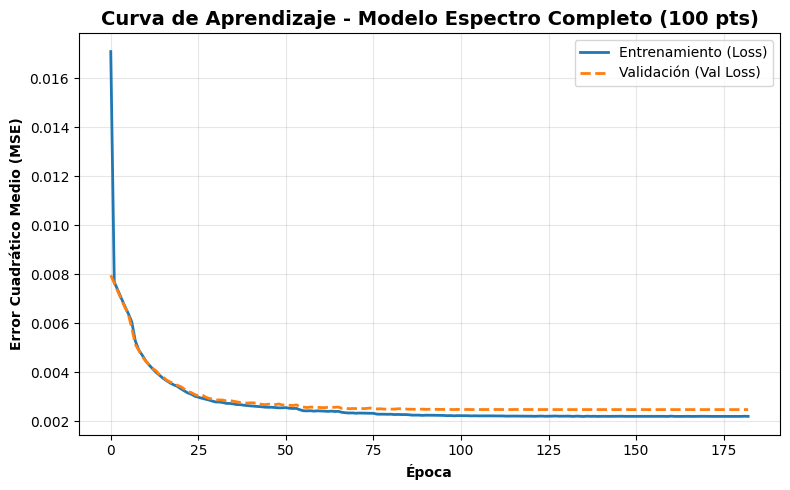

In [13]:
# ====================================================================
# 6. CONFIGURACIÓN Y BUCLE DE ENTRENAMIENTO (EL MOTOR)
# ====================================================================

# Reducir el ratio de aprendizaje si la red se atasca (Paciencia ajustada a 10)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

# Detener el entrenamiento si ya no mejora (Paciencia ajustada a 30)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)

print("Iniciando entrenamiento con 13.000 muestras...")
history = model.fit(
    x=X_train, y=y_train,
    epochs=500,
    batch_size=128, # Lote ampliado para aprovechar los 13.000 datos y estabilizar gradientes
    validation_split=0.15,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ====================================================================
# 7. CURVA DE APRENDIZAJE
# ====================================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Entrenamiento (Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Val Loss)', linewidth=2, linestyle='--')
plt.xlabel('Época', fontweight='bold')
plt.ylabel('Error Cuadrático Medio (MSE)', fontweight='bold')
plt.title('Curva de Aprendizaje - Modelo Espectro Completo (100 pts)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ====================================================================
# PASO 4: EVALUACIÓN PROFESIONAL Y MÉTRICAS PARA EL TUTOR
# ====================================================================
import pandas as pd

# 1. Obtener predicciones en el set de prueba
# Recordamos: y_test y y_pred_norm están en el rango [-1, 1]
y_pred_norm = model.predict(X_test)
y_true_norm = y_test

# 2. Desescalar a escala real (Unidades de intensidad original)
# Usamos el factor_escala_Y que guardamos en la celda 1
y_pred_real = y_pred_norm * factor_escala_Y
y_true_real = y_true_norm * factor_escala_Y

# 3. Función para calcular el bloque de métricas (Igual que en PyTorch)
def get_global_metrics(y_true, y_pred, name_index):
    # Aplanamos para calcular la métrica sobre todos los puntos de todos los espectros
    t = y_true.flatten()
    p = y_pred.flatten()
    
    mae = mean_absolute_error(t, p)
    mse = mean_squared_error(t, p)
    rmse = np.sqrt(mse)
    r2 = r2_score(t, p)
    
    # nMAE y nMSE (Normalizados por el rango real de los datos)
    rango = t.max() - t.min()
    n_mae = mae / (rango if rango != 0 else 1)
    n_mse = mse / (rango**2 if rango != 0 else 1)
    
    # MAPE y Error Máximo
    mape = np.mean(np.abs((t - p) / (np.abs(t) + 1e-8))) * 100
    max_err = np.max(np.abs(t - p))
    
    return pd.DataFrame([[mae, mse, rmse, r2, n_mae, n_mse, mape, max_err]], 
                        columns=['MAE', 'MSE', 'RMSE', 'R2', 'nMAE', 'nMSE', 'MAPE(%)', 'MaxErr'], 
                        index=[name_index])

# 4. Mostrar Tablas de Resultados
print("\n" + "="*95)
print(" TABLA DE MÉTRICAS GLOBALES (MODELO TENSORFLOW - 100 PUNTOS)")
print("="*95)

metrics_norm = get_global_metrics(y_true_norm, y_pred_norm, "Escala Normalizada [-1, 1]")
metrics_real = get_global_metrics(y_true_real, y_pred_real, "Escala Real (Intensidad)")

# Unimos ambas tablas para comparar
df_final = pd.concat([metrics_norm, metrics_real])
display(df_final.round(4))


print("="*95)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

 TABLA DE MÉTRICAS GLOBALES (MODELO TENSORFLOW - 100 PUNTOS)


,MAE,MSE,RMSE,R2,nMAE,nMSE,MAPE(%),MaxErr
"Escala Normalizada [-1, 1]",0.0255,0.0023,0.0476,0.7165,0.0157,0.0009,5.108418e+05,0.7552
Escala Real (Intensidad),37.5052,4903.6170,70.0258,0.7165,0.0157,0.0009,1.664209e+08,1110.1930


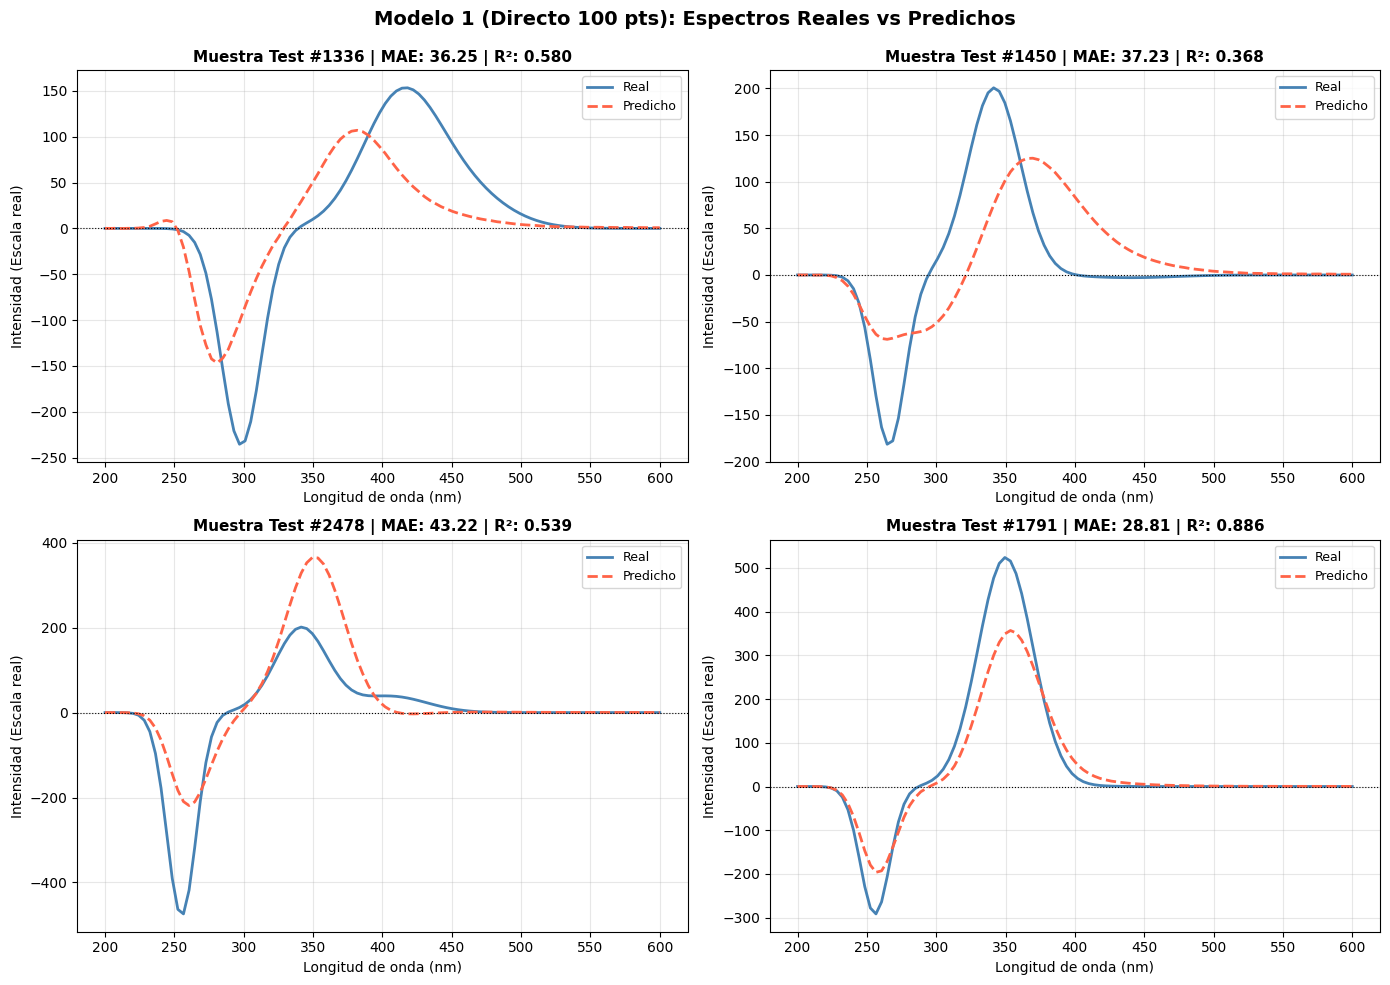

In [15]:
# ====================================================================
# --- VISUALIZAR 4 MUESTRAS (SINCRONIZADO CON MODELO 2) - MODELO 1 ---
# ====================================================================
import matplotlib.pyplot as plt

# 1. Usamos la misma semilla para elegir exactamente las mismas moléculas
np.random.seed(42) 
indices_muestra = np.random.choice(len(y_pred_real), size=4, replace=False)

# 2. Definimos el eje X (Longitudes de onda)
# Si no tienes wl_nm definido, usamos el rango estándar 200-600nm
eje_x = np.linspace(200, 600, 100) 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, indices_muestra):
    # Espectros en escala real
    # y_true_real e y_pred_real vienen de la celda de evaluación anterior
    ax.plot(eje_x, y_true_real[i], label='Real', linewidth=2, color='steelblue')
    ax.plot(eje_x, y_pred_real[i], label='Predicho', linewidth=2, color='tomato', linestyle='--')

    # Calcular métricas locales para esta molécula específica
    mae_i = mean_absolute_error(y_true_real[i], y_pred_real[i])
    r2_i  = r2_score(y_true_real[i], y_pred_real[i])
    
    ax.set_title(f'Muestra Test #{i} | MAE: {mae_i:.2f} | R²: {r2_i:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Intensidad (Escala real)')
    
    # Estética
    ax.axhline(0, color='black', linewidth=0.8, linestyle='dotted')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Modelo 1 (Directo 100 pts): Espectros Reales vs Predichos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Espacio para el título superior
plt.show()

## Guardado de modelo

In [17]:
# 1. Guardar el cerebro de la red neuronal (TensorFlow format)
nombre_modelo = 'envolvente.keras'
model.save(nombre_modelo)

# 2. Guardar el diccionario de configuración y escaladores (Metadatos)
# Aquí metemos el factor de escala, el StandardScaler de scikit-learn y las dimensiones
metadata = {
    'factor_escala_Y': factor_escala_Y,
    'scaler_X': scaler_X,       # ¡Vital para normalizar moléculas nuevas en el futuro!
    'n_features': n_features,
    'n_targets': n_targets,
    # Si tienes un array de longitudes de onda (ej. eje_x), lo puedes añadir aquí:
    # 'eje_x_nm': eje_x 
}

nombre_metadata = 'metadata_envolvente.pkl'
with open(nombre_metadata, 'wb') as f:
    pickle.dump(metadata, f)

print(f"✅ ¡Guardado Exitoso!")
print(f" -> Modelo guardado en: {nombre_modelo}")
print(f" -> Configuración y escaladores guardados en: {nombre_metadata}")

✅ ¡Guardado Exitoso!
 -> Modelo guardado en: envolvente.keras
 -> Configuración y escaladores guardados en: metadata_envolvente.pkl
